In [1]:
import numpy as np
import pandas as pd
import string
import numpy as np
import regex as re
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_csv('/content/drive/MyDrive/CS240PROJECT/WELFake_Dataset.csv',index_col=None)
print(data.info())
data = data.fillna('')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB
None


In [4]:
def preprocess_data(data):
  ''' removing punctuations, deleting alphanumeric characters, converting uppercase characters to lowercase. '''

  data['title_text'] = data['title'] +' '+ data['text']

  data['title_text'] = data['title_text'].astype(str).str.lower()
  data['title_text'] = data['title_text'].str.replace(r'http\S+|www\S+', '', regex=True)

  data['title_text'] = data['title_text'].str.replace(r'#\w+', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'@\w+', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'\S*\*\S*', '', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'\n', ' ', regex=True)
  data['title_text'] = data['title_text'].str.replace(r'[\n\r\t]', ' ', regex=True)

  data['title_text'] = data['title_text'].apply(lambda x: re.sub(r'\p{P}+', '', x))
  data['title_text'] = data['title_text'].apply(lambda x: re.sub(r'[\x00-\x1f\x7f-\x9f]', '', x))
  data['title_text'] = data['title_text'].str.replace(r'\w*\d\w*', '', regex=True)
  data['title_text'] = data['title_text'].apply(lambda x: re.sub(' +',' ',x))

  # data = data.drop(['title','text'],axis=1)
  return data

tmp_data = data.copy()
preprocessed_data = preprocess_data(tmp_data)

In [5]:
preprocessed_data = preprocessed_data[['title','text','title_text','label']]
preprocessed_data.head()

,title,text,title_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,law enforcement on high alert following threat...,1
1,,Did they post their votes for Hillary already?,did they post their votes for hillary already,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",unbelievable obamas attorney general says most...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,bobby jindal raised hindu uses story of christ...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",satan russia unvelis an image of its terrifyin...,1


In [6]:
preprocessed_data.to_csv('preprocessed_data.csv',index=False)

In [ ]:
# !pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [8]:
fake_titles = ' '.join(preprocessed_data[preprocessed_data['label'] == 0]['text'])
real_titles = ' '.join(preprocessed_data[preprocessed_data['label'] == 1]['text'])
fake_wordcloud = WordCloud(
    background_color='black',
    max_words=300,
    width=800,
    height=400,
).generate(fake_titles)
real_wordcloud = WordCloud(
    background_color='black',
    max_words=300,
    width=800,
    height=400,
).generate(real_titles)

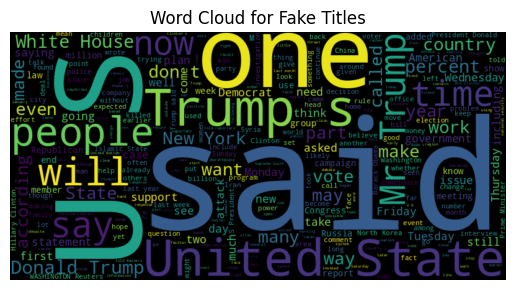

In [10]:
# plt.figure(figsize=(20, 10))
plt.imshow(fake_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Fake Titles')
plt.axis("off")
plt.show()

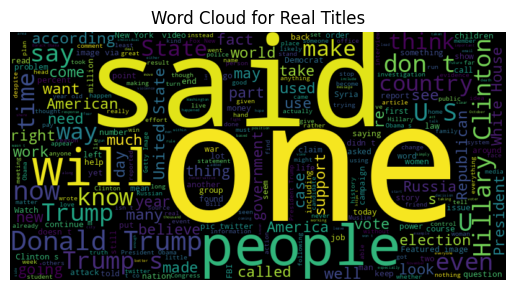

In [11]:
# plt.figure(figsize=(20, 10))
plt.imshow(real_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Real Titles')
plt.axis("off")
plt.show()

In [12]:
preprocessed_data = pd.read_csv('./preprocessed_data.csv',index_col=None)

In [13]:
def tokenize(data):
  if isinstance(data['title_text'][0],list):
    return data
  data['title_text'] = data['title_text'].str.strip()
  data['title_text'] = data['title_text'].apply(lambda x: x.split(' '))
  return data

preprocessed_data = tokenize(preprocessed_data).fillna('')

In [14]:
preprocessed_data.head()

,title,text,title_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,"[law, enforcement, on, high, alert, following,...",1
1,,Did they post their votes for Hillary already?,"[did, they, post, their, votes, for, hillary, ...",1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...","[unbelievable, obamas, attorney, general, says...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,"[bobby, jindal, raised, hindu, uses, story, of...",0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...","[satan, russia, unvelis, an, image, of, its, t...",1


In [15]:
'''splitting the data into test and train '''
train_data, test_data = train_test_split(preprocessed_data, test_size=0.2, random_state=42)

In [28]:
train_data.info()
train_data.iloc[0]['title_text']

<class 'pandas.core.frame.DataFrame'>
Index: 57707 entries, 60264 to 15795
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       57707 non-null  object
 1   text        57707 non-null  object
 2   title_text  57707 non-null  object
 3   label       57707 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.2+ MB


['elon',
 'musks',
 'tesla',
 'stock',
 'up',
 '$',
 'billion',
 'since',
 'joining',
 'trumps',
 'team',
 'although',
 'tesla',
 'ceo',
 'elon',
 'musk',
 'shocked',
 'silicon',
 'valley',
 'by',
 'breaking',
 'ranks',
 'to',
 'become',
 'an',
 'official',
 'member',
 'of',
 'the',
 'white',
 'house',
 'manufacturing',
 'jobs',
 'initiative',
 'the',
 'value',
 'of',
 'his',
 'tesla',
 'stock',
 'is',
 'up',
 'by',
 'over',
 '$',
 'billion',
 'since',
 'the',
 'election',
 'of',
 'donald',
 'trump',
 'as',
 'president',
 'after',
 'a',
 'dizzying',
 'week',
 'of',
 'executive',
 'orders',
 'covering',
 'obamacare',
 'trade',
 'and',
 'immigration',
 'president',
 'trump',
 'held',
 'an',
 'approval',
 'rating',
 'of',
 'percent',
 'of',
 'likely',
 'voters',
 'according',
 'to',
 'the',
 'rasmussen',
 'reports',
 'daily',
 'presidential',
 'tracking',
 'poll',
 'that',
 'is',
 'only',
 'slightly',
 'below',
 'the',
 'percent',
 'level',
 'of',
 'president',
 'obama',
 'when',
 'he',
 

In [ ]:
# !pip uninstall numpy -y
# !pip uninstall gensim -y
# !pip install numpy==1.24.3
# !pip install gensim==4.3.3

from gensim.models import Word2Vec
import numpy as np
def to_word2vec_cbow(news_contents):
  model = Word2Vec(news_contents,vector_size=100,window=5,min_count=5,sg=0)
  news_vectors=[]
  for news in news_contents:
    if news:
      nv = model.wv.get_mean_vector(news)
      news_vectors.append(nv)
    else:
      news_vectors.append(np.zeros(100))

  return news_vectors

news_contents = train_data['title_text'].copy()
news_contents = news_contents.to_list()
print(news_contents[0])
news_vectors = to_word2vec_cbow(news_contents)


Found existing installation: numpy 1.24.3
Uninstalling numpy-1.24.3:
  Successfully uninstalled numpy-1.24.3
Found existing installation: gensim 4.3.3
Uninstalling gensim-4.3.3:
  Successfully uninstalled gensim-4.3.3
  Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.3 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.3 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.


  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
['elon', 'musks', 'tesla', 'stock', 'up', '$', 'billion', 'since', 'joining', 'trumps', 'team', 'although', 'tesla', 'ceo', 'elon', 'musk', 'shocked', 'silicon', 'valley', 'by', 'breaking', 'ranks', 'to', 'become', 'an', 'official', 'member', 'of', 'the', 'white', 'house', 'manufacturing', 'jobs', 'initiative', 'the', 'value', 'of', 'his', 'tesla', 'stock', 'is', 'up', 'by', 'over', '$', 'billion', 'since', 'the', 'election', 'of', 'donald', 'trump', 'as', 'president', 'after', 'a', 'dizzying', 'week', 'of', 'executive', 'orders', 'covering', 'obamacare', 'trade', 'and', 'immigration', 'president', 'trump', 'held', 'an', 'approval', 'rating', 'of', 'percent', 'of', 'likely', 'voters', 'according', 'to', 'the', 'rasmussen', 'reports', 'daily', 'presidential', 'tracking', 'poll', 'that', 'is

In [37]:
# print(news_vectors.shape)
# print(len(news_contents))
# print(len(train_data['title_text']))

(57707, 100)
57707
57707


In [19]:
news_vectors = np.array(news_vectors)

In [20]:
news_vectors_test = to_word2vec_cbow(test_data['title_text'].to_list())
news_vectors_test = np.array(news_vectors_test)

In [21]:
np.save('test_data_cbow.npy',news_vectors_test)

In [22]:
## save this numpy array
np.save('train_data_cbow.npy',news_vectors)